# Analyze Logistic Regression Predictions
This notebook analyzes the results of the trained logistic regression model and explores the most impactful features on each class.

These terms may be helpful to understand the features better.  
- Entropy: Measures how irregular / unpredictable a signal is.
- Correlation: Measures how much two axes move together.
- arCoeff: Autoregressive coefficient describes how much the current signal depends on its previous values.
- bandsEnergy: Describes energy in a specific frequency range.
- Gravity acceleration energy: How strong / concentrated the gravity component is over the time window.
- Kurtosis: Measures how peaked or heavy-tailed a signal’s distribution is.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
MODEL_PATH = "../checkpoints/logistic-regression-2026-04-04-21-23.npz"
features_df = pd.read_csv("../data/features.txt", sep="\s+", header=None, names=["index", "feature_name"], index_col="index")
feature_map = features_df.to_dict()["feature_name"]


In [3]:
data = np.load(MODEL_PATH, allow_pickle=True)
print("Keys in file:", data.files)
CLASS_NAMES = [str(x) for x in data["target_names"].tolist()]
W = data["weight_matrix"]           # shape: (6, 561)
b = data["bias_vector"].reshape(-1) # shape: (6,)
FEATURE_NAMES = [f"{feature_map[i]}" for i in range(1, W.shape[1] + 1)]

print("W shape:", W.shape)
print("b shape:", b.shape)
print("Classes:", CLASS_NAMES)

if "max_iter" in data.files:
    print("max_iter:", int(data["max_iter"]))
if "random_state" in data.files:
    print("random_state:", int(data["random_state"]))
if "learning_rate" in data.files:
    print("learning_rate:", float(data["learning_rate"]))

Keys in file: ['weight_matrix', 'bias_vector', 'max_iter', 'random_state', 'learning_rate', 'target_names']
W shape: (6, 561)
b shape: (6,)
Classes: ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING']
max_iter: 10000
random_state: 42
learning_rate: 0.05



=== WALKING ===

Top positive weights:
tBodyAccJerk-correlation()-X,Y  0.4665
tBodyGyroJerk-correlation()-X,Z  0.4657
tBodyAcc-correlation()-X,Y  0.3771

Top negative weights:
tGravityAcc-entropy()-X -0.4138
fBodyAccMag-energy() -0.2860
fBodyAcc-bandsEnergy()-1,8 -0.2301


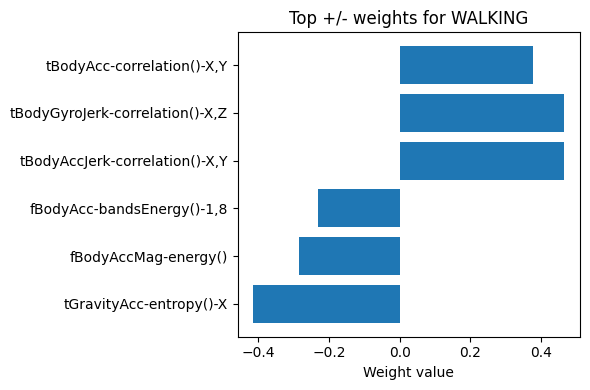


=== WALKING_UPSTAIRS ===

Top positive weights:
tGravityAcc-entropy()-X  0.3857
tGravityAcc-sma()     0.3683
fBodyGyro-kurtosis()-Z  0.2642

Top negative weights:
tBodyGyroJerk-correlation()-X,Z -0.4533
tBodyAccJerk-min()-X -0.3358
tBodyGyroJerk-correlation()-X,Y -0.3137

=== WALKING_DOWNSTAIRS ===

Top positive weights:
tBodyAccJerk-max()-X  0.3526
fBodyAccMag-energy()  0.3266
tBodyAcc-arCoeff()-X,4  0.3102

Top negative weights:
tBodyGyro-correlation()-Y,Z -0.3976
tBodyAcc-correlation()-X,Y -0.3668
tBodyAccJerk-correlation()-Y,Z -0.3190

=== SITTING ===

Top positive weights:
tGravityAcc-mean()-Y  0.6766
tGravityAcc-max()-Y   0.6522
tGravityAcc-min()-Y   0.6244

Top negative weights:
tBodyGyroJerk-entropy()-X -1.1143
fBodyGyro-entropy()-X -0.7378
tGravityAcc-energy()-Y -0.5557

=== STANDING ===

Top positive weights:
tBodyGyroJerk-entropy()-X  1.0056
angle(Y,gravityMean)  0.7488
fBodyGyro-entropy()-X  0.6094

Top negative weights:
tGravityAcc-mean()-Y -0.8723
tGravityAcc-min()-Y  -0

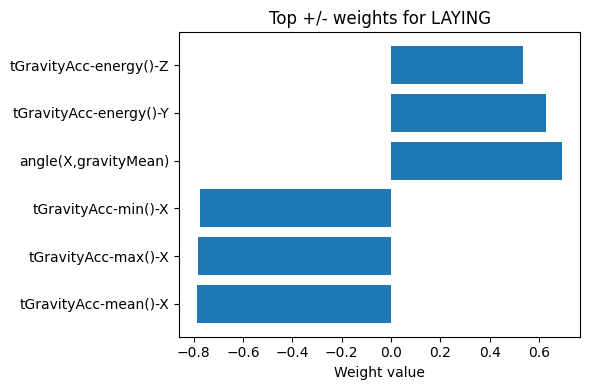

In [4]:
# Examine the top weights for each class
def show_top_weights_for_class(class_idx: int, top_k: int=10) -> None:
    """
    Show the top k positive and negative weights for a given class.
    """
    w = W[class_idx]
    pos_idx = np.argsort(w)[-top_k:][::-1]
    neg_idx = np.argsort(w)[:top_k]

    print(f"\n=== {CLASS_NAMES[class_idx]} ===")

    print("\nTop positive weights:")
    for i in pos_idx:
        print(f"{FEATURE_NAMES[i]:<20} {w[i]: .4f}")

    print("\nTop negative weights:")
    for i in neg_idx:
        print(f"{FEATURE_NAMES[i]:<20} {w[i]: .4f}")


def plot_top_weights_for_class(class_idx: int, top_k: int=10) -> None:
    """
    Plot the top k positive and negative weights for a given class.
    """
    w = W[class_idx]
    pos_idx = np.argsort(w)[-top_k:][::-1]
    neg_idx = np.argsort(w)[:top_k]

    idx = np.concatenate([neg_idx, pos_idx])
    vals = w[idx]
    labels = [FEATURE_NAMES[i] for i in idx]

    plt.figure(figsize=(6, 4))
    plt.barh(range(len(idx)), vals)
    plt.yticks(range(len(idx)), labels)
    plt.xlabel("Weight value")
    plt.title(f"Top +/- weights for {CLASS_NAMES[class_idx]}")
    plt.tight_layout()
    plt.show()


for c in range(len(CLASS_NAMES)):
    show_top_weights_for_class(c, top_k=3)
    if c in [0, 5]:
        plot_top_weights_for_class(c, top_k=3)


=== Top global features ===
tBodyGyroJerk-entropy()-X  1.5093
tGravityAcc-mean()-Y  1.1642
tGravityAcc-max()-Y   1.1519
tGravityAcc-min()-Y   1.1277
angle(Y,gravityMean)  0.9895
fBodyGyro-entropy()-X  0.9614
tGravityAcc-mean()-X  0.9608
tGravityAcc-max()-X   0.9491
tGravityAcc-min()-X   0.9491
tGravityAcc-energy()-Y  0.8729
angle(X,gravityMean)  0.8598
tGravityAcc-energy()-X  0.8339
tBodyGyroJerk-arCoeff()-X,2  0.8317
tBodyGyroJerk-arCoeff()-X,1  0.7899
tBodyAcc-correlation()-X,Y  0.7468
tGravityAcc-energy()-Z  0.7191
tBodyGyro-entropy()-X  0.6864
tBodyGyro-arCoeff()-X,1  0.6717
tBodyGyroJerk-correlation()-X,Z  0.6529
tBodyGyroJerk-arCoeff()-X,3  0.5994


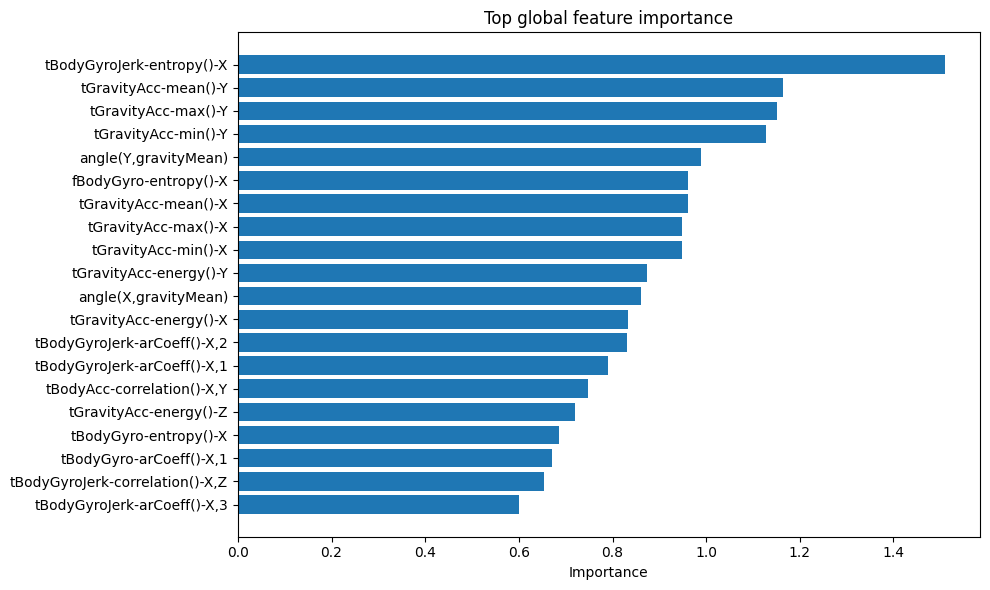

In [5]:
# Global feature importance
importance = np.linalg.norm(W, axis=0)
top_idx = np.argsort(importance)[-20:][::-1]

print("\n=== Top global features ===")
for i in top_idx:
    print(f"{FEATURE_NAMES[i]:<20} {importance[i]: .4f}")

plt.figure(figsize=(10, 6))
plt.barh(range(len(top_idx)), importance[top_idx][::-1])
plt.yticks(range(len(top_idx)), [FEATURE_NAMES[i] for i in top_idx][::-1])
plt.xlabel("Importance")
plt.title("Top global feature importance")
plt.tight_layout()
plt.show()


=== WALKING vs LAYING ===

Most favoring WALKING:
tGravityAcc-mean()-X  0.8687
tGravityAcc-max()-X   0.8550
tGravityAcc-min()-X   0.8378

Most favoring LAYING:
angle(X,gravityMean) -0.8021
tGravityAcc-energy()-Y -0.7220
tGravityAcc-energy()-Z -0.5780


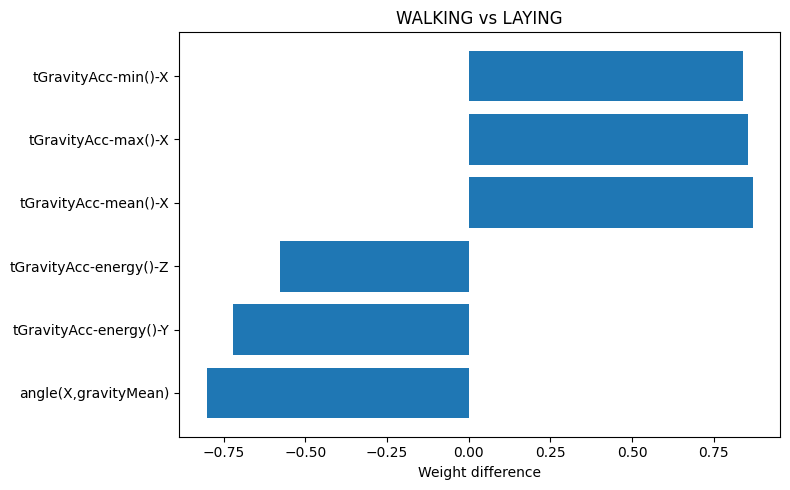


=== SITTING vs STANDING ===

Most favoring SITTING:
tGravityAcc-mean()-Y  1.5489
tGravityAcc-max()-Y   1.5146
tGravityAcc-min()-Y   1.4871

Most favoring STANDING:
tBodyGyroJerk-entropy()-X -2.1199
fBodyGyro-entropy()-X -1.3472
angle(Y,gravityMean) -1.2443


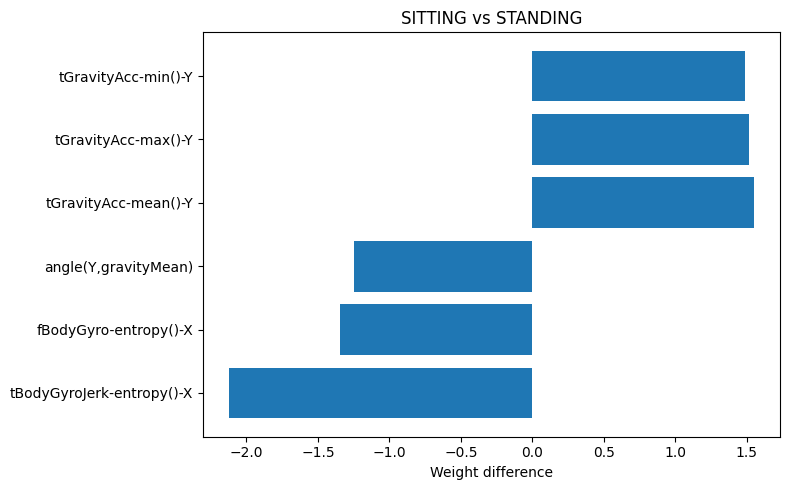


=== WALKING_UPSTAIRS vs WALKING_DOWNSTAIRS ===

Most favoring WALKING_UPSTAIRS:
tGravityAcc-sma()     0.6138
tBodyGyro-correlation()-Y,Z  0.6052
fBodyGyro-kurtosis()-Z  0.5370

Most favoring WALKING_DOWNSTAIRS:
tBodyAccJerk-min()-X -0.5647
tBodyAccJerk-max()-X -0.5393
tBodyGyroJerk-correlation()-X,Y -0.4938


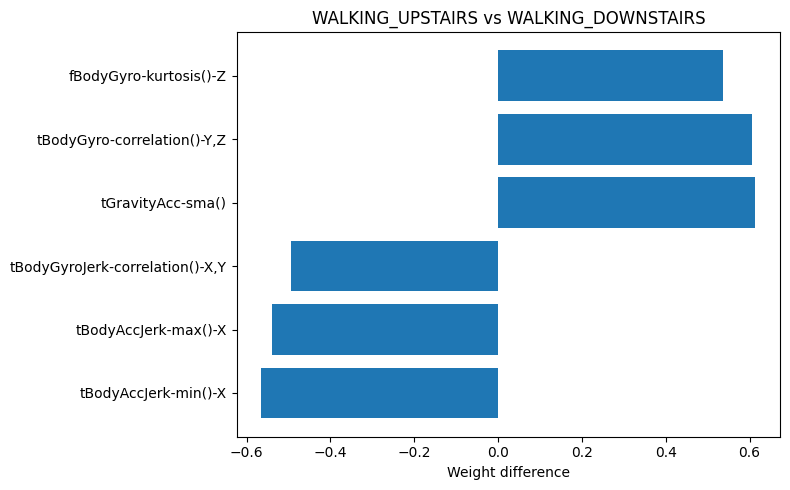

In [8]:
def compare_classes(a_idx: int, b_idx: int, top_k: int=10) -> None:
    """
    Compare two classes by analyzing the difference in their weight vectors.
    Compute the feature-wise difference between the weights
    of class a_idx and class b_idx:

        diff = W[a_idx] - W[b_idx]

    Features with the largest positive differences favor class a_idx,
    while features with the largest negative differences favor class b_idx.
    """
    diff = W[a_idx] - W[b_idx]
    pos_idx = np.argsort(diff)[-top_k:][::-1]
    neg_idx = np.argsort(diff)[:top_k]

    print(f"\n=== {CLASS_NAMES[a_idx]} vs {CLASS_NAMES[b_idx]} ===")

    print(f"\nMost favoring {CLASS_NAMES[a_idx]}:")
    for i in pos_idx:
        print(f"{FEATURE_NAMES[i]:<20} {diff[i]: .4f}")

    print(f"\nMost favoring {CLASS_NAMES[b_idx]}:")
    for i in neg_idx:
        print(f"{FEATURE_NAMES[i]:<20} {diff[i]: .4f}")

    idx = np.concatenate([neg_idx, pos_idx])
    vals = diff[idx]
    labels = [FEATURE_NAMES[i] for i in idx]

    plt.figure(figsize=(8, 5))
    plt.barh(range(len(idx)), vals)
    plt.yticks(range(len(idx)), labels)
    plt.xlabel("Weight difference")
    plt.title(f"{CLASS_NAMES[a_idx]} vs {CLASS_NAMES[b_idx]}")
    plt.tight_layout()
    plt.show()


compare_classes(0, 5, top_k=3)
compare_classes(3, 4, top_k=3)
compare_classes(1, 2, top_k=3)


=== Biases ===
WALKING               0.0618
WALKING_UPSTAIRS     -0.0300
WALKING_DOWNSTAIRS   -0.0326
SITTING               0.0056
STANDING             -0.0184
LAYING                0.0135


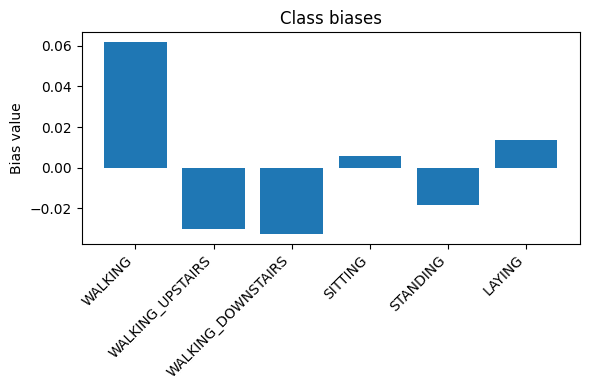

In [7]:
# Compare the biases of classes
print("\n=== Biases ===")
for name, val in zip(CLASS_NAMES, b):
    print(f"{name:<20} {val: .4f}")

plt.figure(figsize=(6, 4))
plt.bar(range(len(CLASS_NAMES)), b)
plt.xticks(range(len(CLASS_NAMES)), CLASS_NAMES, rotation=45, ha="right")
plt.ylabel("Bias value")
plt.title("Class biases")
plt.tight_layout()
plt.show()

According to observations above, while there are so many features involved in predicting the motion, the model mainly relies on orientation-based features to predict static classes such gravity acceleration, angle, etc., and for dynamic classes, it more depends on features that measure some sort of change in a parameter such as acceleration entropy. In addition, the small magnitudes of bias for all classes indicates that the model doesn't strongly favor a class over the others. 